In [50]:
# Data Cleaning
import pandas as pd
import numpy as np

# Visulization
import matplotlib.pyplot as plt
import seaborn as sns

# Warning
import warnings
warnings.filterwarnings('ignore')


# Data Cleaning

In [51]:
data = pd.read_csv("student_performance_prediction_dataset-2.csv")

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [102]:
data.shape

(299996, 25)

In [103]:
data.isna().sum()

age                      0
gender                   0
study_hours              0
attendance               0
sleep_hours              0
previous_grade           0
assignments_completed    0
practice_tests_taken     0
group_study_hours        0
notes_quality_score      0
time_management_score    0
motivation_level         0
mental_health_score      0
screen_time              0
social_media_hours       0
family_income            0
parent_education         0
internet_access          0
device_type              0
school_type              0
extracurriculars         0
final_grade              0
grade_category           0
pass_fail                0
motivation_level_cat     0
dtype: int64

In [7]:
for col in data.columns:
    if data[col].isna().sum():
        print([col], round(((data[col].isna().sum())/data.shape[0])*100, 5),'% Nan Ha  Unique Value --->> ', data[col].unique())

['device_type'] 5.035 % Nan Ha  Unique Value --->>  ['Mobile' 'Laptop' 'Tablet' nan]
['extracurriculars'] 16.66033 % Nan Ha  Unique Value --->>  ['Coding Club' nan 'Music' 'Debate' 'Sports' 'Arts']
['grade_category'] 0.00133 % Nan Ha  Unique Value --->>  ['D' 'A' 'F' 'C' 'B' 'A+' nan]


In [56]:
data.dropna(subset=['grade_category'], inplace=True)
data.device_type.fillna(data.device_type.mode()[0], inplace=True)
data.extracurriculars.fillna(data.extracurriculars.mode()[0], inplace=True)

In [55]:
data.drop(columns=['student_id'], axis=1, inplace=True)

# EDA (Exploratory Data Analysis)

In [57]:
data.select_dtypes('number').corr()

,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
age,1.000000,0.001830,-0.001173,-0.002122,-0.003496,-0.001805,-0.001902,0.000406,0.000393,0.000657,-0.000024,-0.001231,-0.001305,-0.002008,-0.000637
study_hours,0.001830,1.000000,0.000071,0.000065,-0.001463,0.002749,-0.000527,0.000824,-0.000478,0.003399,0.004837,0.003864,0.001161,-0.003672,0.430964
attendance,-0.001173,0.000071,1.000000,0.003092,-0.002547,0.002937,-0.001342,0.001037,-0.001342,0.001311,0.001500,0.001914,-0.000708,-0.001389,0.204708
sleep_hours,-0.002122,0.000065,0.003092,1.000000,0.002486,0.000473,-0.000241,0.000377,0.000884,0.001605,0.003243,0.000597,-0.003061,-0.000476,0.122943
previous_grade,-0.003496,-0.001463,-0.002547,0.002486,1.000000,0.000085,0.001451,0.002399,-0.002793,-0.001835,-0.002218,-0.002161,0.000845,-0.001293,0.393323
assignments_completed,-0.001805,0.002749,0.002937,0.000473,0.000085,1.000000,-0.001022,-0.000975,0.002025,-0.001512,-0.000561,-0.000453,-0.003463,0.001893,0.281999
practice_tests_taken,-0.001902,-0.000527,-0.001342,-0.000241,0.001451,-0.001022,1.000000,0.001931,-0.001103,0.002030,0.000642,0.003604,-0.001493,-0.000768,0.213134
group_study_hours,0.000406,0.000824,0.001037,0.000377,0.002399,-0.000975,0.001931,1.000000,0.001872,-0.004154,0.002063,-0.002013,0.000028,0.001654,0.075734
notes_quality_score,0.000393,-0.000478,-0.001342,0.000884,-0.002793,0.002025,-0.001103,0.001872,1.000000,-0.001591,-0.000045,-0.001556,0.001915,0.000034,0.201452
time_management_score,0.000657,0.003399,0.001311,0.001605,-0.001835,-0.001512,0.002030,-0.004154,-0.001591,1.000000,0.000138,0.001069,0.001243,-0.000555,0.312727


In [58]:
data.columns

Index(['age', 'gender', 'study_hours', 'attendance', 'sleep_hours',
       'previous_grade', 'assignments_completed', 'practice_tests_taken',
       'group_study_hours', 'notes_quality_score', 'time_management_score',
       'motivation_level', 'mental_health_score', 'screen_time',
       'social_media_hours', 'family_income', 'parent_education',
       'internet_access', 'device_type', 'school_type', 'extracurriculars',
       'final_grade', 'grade_category', 'pass_fail'],
      dtype='object')

### Comparision Chart

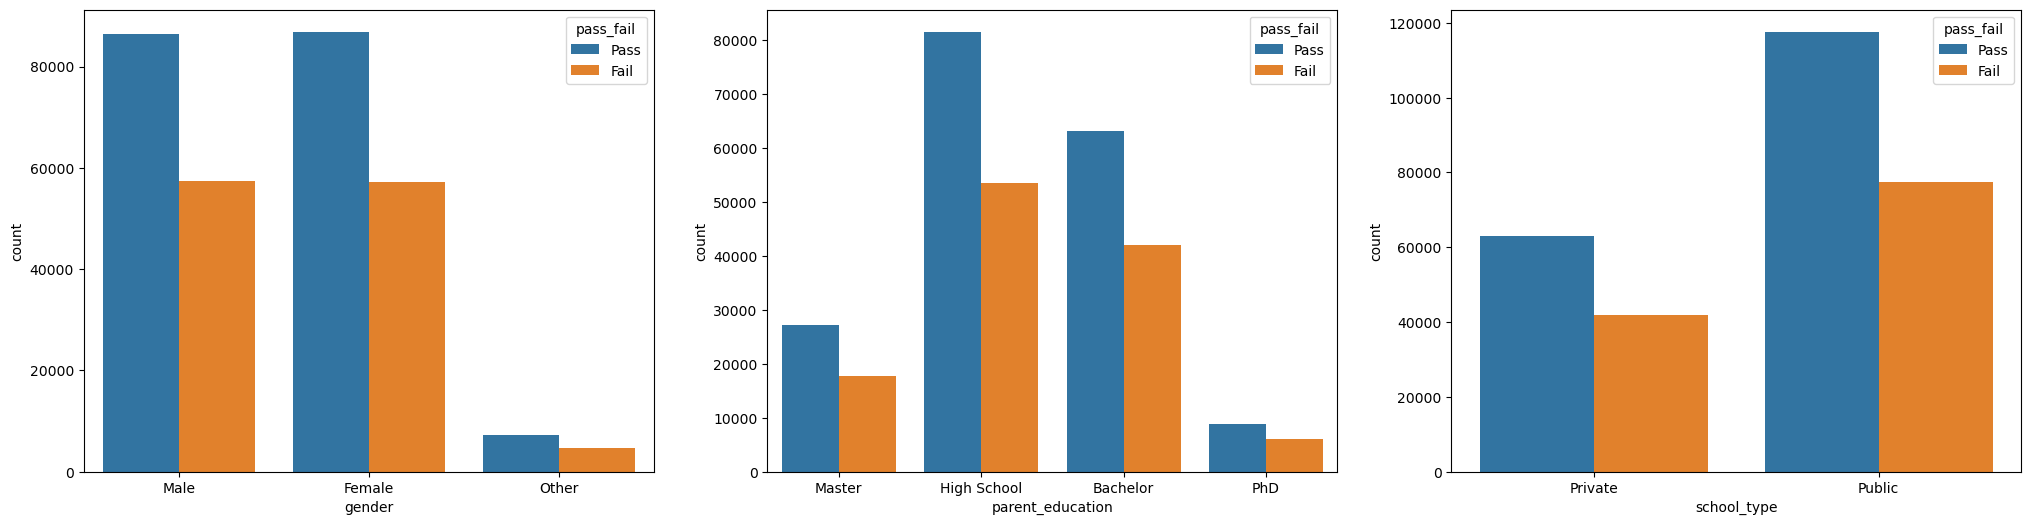

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(25,6))
for i, col in enumerate(['gender', 'parent_education', 'school_type']):
    sns.countplot(data = data, x =data[col], hue = data.pass_fail , ax=axes[i])

<Axes: xlabel='age', ylabel='pass_fail'>

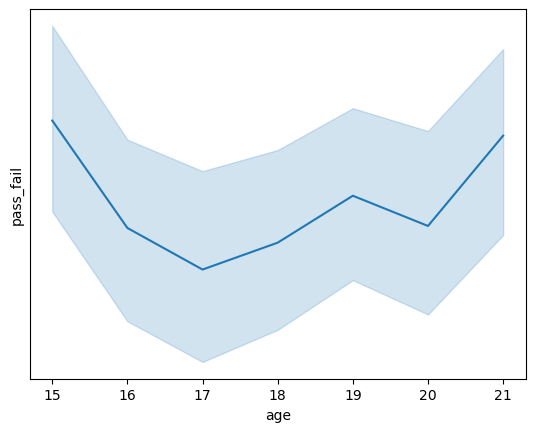

In [13]:
sns.lineplot(data = data, x= data.age, y= data.pass_fail)

In [70]:
data['motivation_level_cat'] =  pd.qcut(x=data.motivation_level, q= 3, labels=['low', 'High', 'Extremely_High'])

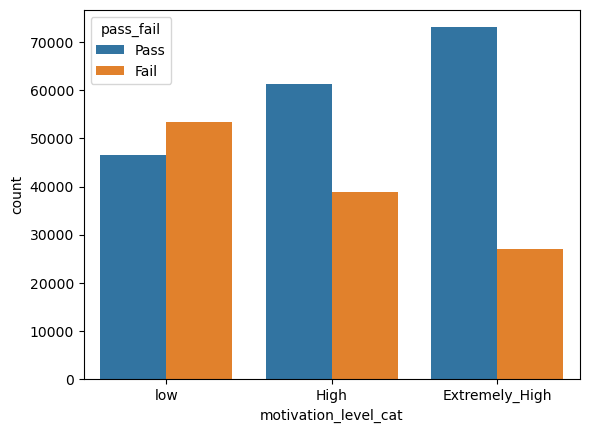

In [15]:
sns.countplot(data=data, x= 'motivation_level_cat', hue='pass_fail')
plt.show()

## Feature Engineering

In [73]:
x = data.drop(columns = ['pass_fail','grade_category','final_grade'])
y = data['pass_fail']

In [74]:
x.shape

(299996, 22)

In [75]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [76]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((239996, 22), (60000, 22), (239996,), (60000,))

#### Encoding

In [77]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [78]:
x_train.select_dtypes(include=['object', 'category'])

,gender,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,motivation_level_cat
83577,Male,Medium,High School,Yes,Laptop,Public,Arts,High
237955,Male,Medium,Master,Yes,Laptop,Public,Arts,Extremely_High
5013,Female,Low,High School,Yes,Laptop,Public,Debate,low
44964,Male,Low,High School,Yes,Mobile,Private,Debate,low
86935,Male,High,Bachelor,Yes,Laptop,Private,Arts,High
...,...,...,...,...,...,...,...,...
119881,Female,Low,High School,Yes,Tablet,Private,Debate,Extremely_High
259182,Female,Medium,Bachelor,No,Laptop,Public,Arts,Extremely_High
131934,Male,Medium,Bachelor,Yes,Laptop,Public,Arts,Extremely_High
146869,Male,Low,PhD,Yes,Laptop,Public,Arts,High


In [79]:
for col in x_train.select_dtypes(include=['object', 'category']):
    print(col, '=', data[col].nunique())

gender = 3
family_income = 3
parent_education = 4
internet_access = 2
device_type = 3
school_type = 2
extracurriculars = 5
motivation_level_cat = 3


In [80]:
# One Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.set_output(transform='pandas')
x_train_ohe = ohe.fit_transform(x_train[['gender', 'extracurriculars','device_type']])
x_test_ohe = ohe.transform(x_test[['gender', 'extracurriculars','device_type']])

In [81]:
# Ordinal Encoding
#orders
family_income = ['Low', 'Medium', 'High']
parent_education = ['High School','Bachelor', 'Master','PhD']
motivation_level_cat = ['low', 'High', 'Extremely_High']
col_to_encode = ['family_income', 'parent_education', 'motivation_level_cat']

ode = OrdinalEncoder(categories=[family_income, parent_education, motivation_level_cat])
ode.set_output(transform='pandas')
x_train_ode = ode.fit_transform(x_train[col_to_encode])
x_test_ode = ode.transform(x_test[col_to_encode])

In [82]:
# Label Encoding
le = LabelEncoder()
leb = LabelEncoder()

x_train_le = pd.DataFrame({'internet_access' : le.fit_transform(x_train['internet_access']), "schol_type" : leb.fit_transform(x_train['school_type']) })
x_test_le = pd.DataFrame({'internet_access' : le.transform(x_test['internet_access']), "schol_type" : leb.transform(x_test['school_type']) })



In [83]:
for col in x_train.select_dtypes(include=['object', 'category']):
    x_train.drop(columns=[col], inplace=True, axis=1)
    x_test.drop(columns=[col], inplace=True, axis=1)

In [84]:
x_train_encoded = pd.concat([x_train, x_train_ohe, x_train_ode, x_train_le.set_index(x_train.index)], axis=1 )

In [85]:
x_test_encoded = pd.concat([x_test, x_test_ohe, x_test_ode, x_test_le.set_index(x_test.index)], axis=1 )

In [86]:
# Lael encdoing pn labels

lel = LabelEncoder()

y_train = lel.fit_transform(y_train)
y_test = lel.transform(y_test)

### Scaling

In [87]:
x_train.select_dtypes('number').describe()

,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours
count,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000,239996.000000
mean,18.002196,4.503704,84.681198,6.992073,69.836002,7.834631,4.019463,1.528413,6.944328,6.465149,6.943984,6.982283,4.018209,2.527626
std,1.999039,1.981709,9.430134,1.462639,14.679461,1.731741,1.956841,0.941420,1.884327,1.926248,1.887614,1.471582,1.958778,1.434872
min,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16.000000,3.142261,78.216801,5.995059,59.861690,6.653544,2.655902,0.825464,5.653792,5.139425,5.649951,5.979601,2.649838,1.489043
50%,18.000000,4.497956,84.975044,7.000878,69.956443,7.998926,4.004157,1.498558,7.010744,6.493970,7.002144,6.991397,3.997134,2.495602
75%,20.000000,5.850618,91.723733,8.012791,80.094334,9.352808,5.352197,2.172588,8.350781,7.847256,8.357909,8.008767,5.351626,3.510399
max,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.set_output(transform='pandas')
x_train_scaled = scaler.fit_transform(x_train_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

In [89]:
x_test_scaled.head(5)

,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,...,extracurriculars_Music,extracurriculars_Sports,device_type_Laptop,device_type_Mobile,device_type_Tablet,family_income,parent_education,motivation_level_cat,internet_access,schol_type
152228,-0.501340,0.997965,1.188406,0.154098,0.618726,-0.038058,-1.621315,-1.307836,0.876893,0.202711,...,-0.446977,-0.445929,0.817692,-0.656500,-0.332441,0.207955,-0.917874,0.001086,0.420068,0.733789
125074,-0.001098,0.733362,1.020275,-0.580302,-1.592646,-0.684820,-0.717097,0.149519,-2.914694,1.059213,...,-0.446977,-0.445929,0.817692,-0.656500,-0.332441,-1.168713,0.232205,-1.222758,0.420068,-1.362790
154608,-1.501823,-0.683841,0.602718,0.003967,0.336619,-0.671995,-2.054061,1.510231,1.233747,-0.165053,...,-0.446977,-0.445929,0.817692,-0.656500,-0.332441,0.207955,-0.917874,-1.222758,0.420068,0.733789
42457,-0.501340,-0.741136,0.960246,-1.614098,1.130333,-1.720955,-0.315506,-1.623522,-1.035182,0.949864,...,-0.446977,-0.445929,-1.222954,1.523229,-0.332441,1.584622,-0.917874,0.001086,0.420068,0.733789
267856,-1.501823,0.193233,-0.270837,1.963212,-0.386506,0.075143,-0.743357,-1.048676,-1.402487,-2.670126,...,-0.446977,-0.445929,-1.222954,-0.656500,3.008056,-1.168713,-0.917874,-1.222758,0.420068,0.733789


## Building Model

In [90]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [136]:
model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(512, activation='relu'),
    Dense(250, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [137]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [138]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [139]:
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.8656 - loss: 0.2943 - val_accuracy: 0.8680 - val_loss: 0.2903
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8691 - loss: 0.2876 - val_accuracy: 0.8659 - val_loss: 0.2914
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.8697 - loss: 0.2858 - val_accuracy: 0.8688 - val_loss: 0.2891
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8703 - loss: 0.2846 - val_accuracy: 0.8681 - val_loss: 0.2899
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8709 - loss: 0.2835 - val_accuracy: 0.8682 - val_loss: 0.2903
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8713 - loss: 0.2830 - val_accuracy: 0.8687 - val_loss: 0.2893
Epoch 7/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8717 - loss: 0.2817 - val_accuracy: 0.8687 - val_loss: 0.2885
Epoch 8/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8721 - loss: 0

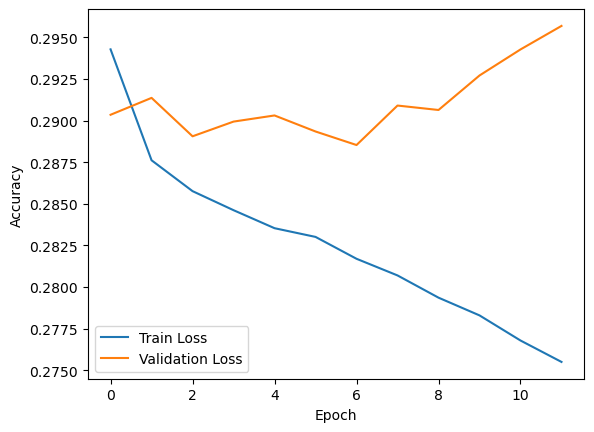

In [142]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [121]:
y_test_predict = model.predict(x_test_scaled)
y_train_predict = model.predict(x_train_scaled)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


In [128]:
# convert the percentage prediction into actual prediction
test_pred = np.where(y_test_predict>=0.5, 1, 0)
train_pred = np.where(y_train_predict>=0.5, 1, 0)

### Model Evaluation

In [133]:
# classification report on train data
from sklearn.metrics import classification_report

print(classification_report(y_train, train_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84     95643
           1       0.89      0.90      0.89    144353

    accuracy                           0.87    239996
   macro avg       0.87      0.86      0.87    239996
weighted avg       0.87      0.87      0.87    239996



In [134]:
# classfictaion report on test data

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83     23624
           1       0.89      0.90      0.89     36376

    accuracy                           0.87     60000
   macro avg       0.87      0.86      0.86     60000
weighted avg       0.87      0.87      0.87     60000



In [127]:
model.evaluate(x_test_scaled, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8704 - loss: 0.2845


[0.2844897508621216, 0.8704166412353516]

In [135]:
model.evaluate(x_train_scaled, y_train)

7500/7500 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.8713 - loss: 0.2819


[0.28191548585891724, 0.8713103532791138]

## Conclusion

In this assignment, I developed a Neural Network classification model to predict students' Pass/Fail outcomes. The data was preprocessed using appropriate encoding and feature scaling techniques before training the model. I used validation data and the EarlyStopping callback to monitor the model's performance and automatically retain the best model weights.

The final model achieved approximately **87% accuracy** on the test dataset. The results show that the model was able to learn meaningful patterns from the available student-related features while maintaining similar performance on training, validation, and test data.
